# 🖼️ Lecture & Lab: Computer Vision with ANN — MNIST Digits
### 🎓 Simple, Minimal-Code Image Classification with Keras

---

## 📌 What You Will Learn Today
1. **How Images are Represented**: 2D pixel grids ($28 \times 28$) with values from $0$ (Black) to $255$ (White)
2. **Preprocessing**: Normalization ($X / 255.0$) and Flattening ($28 \times 28 \rightarrow 784$)
3. **Multi-Class Output**: 10 output neurons with **Softmax** activation
4. **Preventing Overfitting**: Using **Dropout**
5. **Ultra-Easy Visualization**:
   - 4-line image grid plot
   - 1-line training curves with `pd.DataFrame(history.history).plot()`
   - 1-line $10 \times 10$ Confusion Matrix with `ConfusionMatrixDisplay`
   - Inspecting misclassified digits in 4 lines
   - 1-sample prediction with `model.predict()`


### 📦 Step 1: Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Sklearn for quick metrics
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


---
## 2. 📂 Load & Explore MNIST Dataset


In [2]:
# 1. Load MNIST (60k train, 10k test)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (60000, 28, 28), Test Shape: (10000, 28, 28)


### 🎨 Easy 4-Line Image Grid Plot

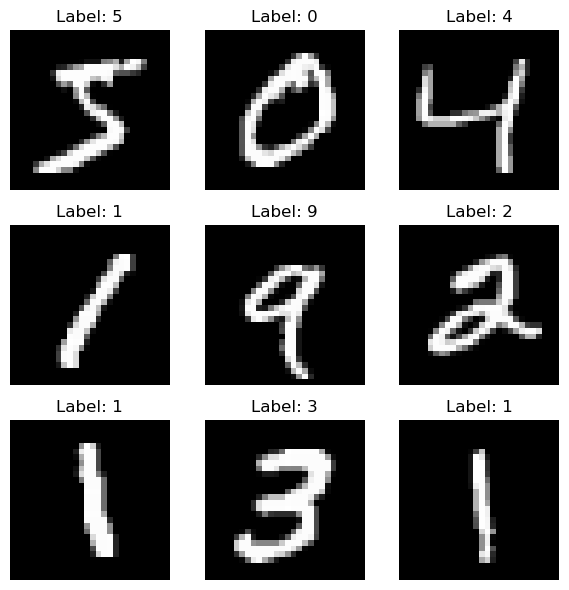

In [3]:
# Display 9 sample digits
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---
## 3. ⚙️ Preprocessing: Normalize Pixel Values ($0-255 \rightarrow 0.0-1.0$)


In [4]:
# Normalize to range [0.0, 1.0] by dividing by 255.0
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Min: {X_train.min()}, Max: {X_train.max()}")

Min: 0.0, Max: 1.0


---
## 4. 🏗️ Build the Neural Network Architecture


In [5]:
# Deep Neural Network for 10-class digit classification
model = Sequential([
    Flatten(input_shape=(28, 28)),    # Converts 28x28 2D image into 784 1D vector
    Dense(128, activation='relu'),     # Hidden Layer 1: 128 neurons
    Dropout(0.2),                     # Regularization: randomly drops 20% neurons to prevent overfitting
    Dense(64, activation='relu'),      # Hidden Layer 2: 64 neurons
    Dense(10, activation='softmax')   # Output Layer: 10 neurons (probabilities for digits 0-9)
])

model.summary()

C:\Users\moham\miniconda3\envs\Training-env-tf\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

---
## 5. 🚀 Compile & Train the Model


In [6]:
# Compile with sparse categorical crossentropy (for integer labels 0-9)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model for 10 epochs
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


  1/422 ━━━━━━━━━━━━━━━━━━━━ 6:35 940ms/step - accuracy: 0.0703 - loss: 2.3966

 23/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3259 - loss: 2.0243    

 47/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4583 - loss: 1.7215

 71/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5357 - loss: 1.5057

...

340/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0517

365/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0517

390/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0517

415/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0516

422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.0514 - val_accuracy: 0.9817 - val_loss: 0.0677


---
## 6. 📈 The Easiest Way to Plot Training Curves: `pd.DataFrame(history.history).plot()`


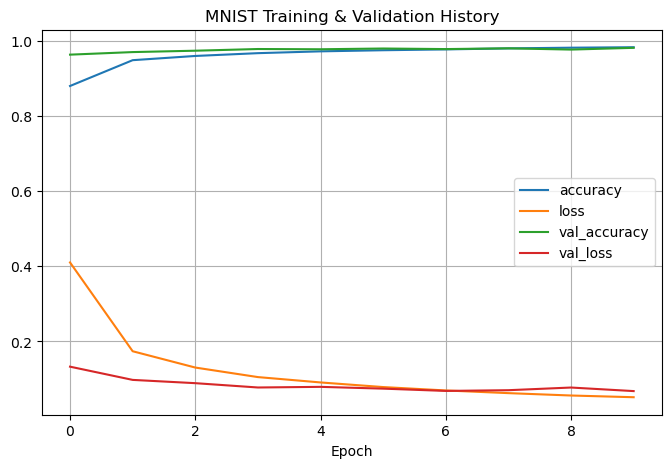

In [7]:
# 1-Line Plot for Loss and Accuracy!
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("MNIST Training & Validation History")
plt.xlabel("Epoch")
plt.grid(True)
plt.show()

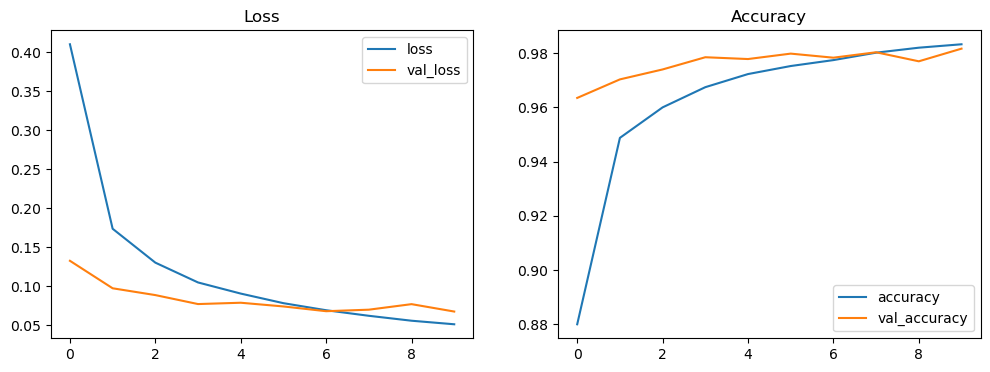

In [8]:
# Side-by-Side Loss vs Accuracy (Clean 4 lines)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(ax=ax1, title="Loss")
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot(ax=ax2, title="Accuracy")
plt.show()

---
## 7. 🎯 Test Set Evaluation & 1-Line Confusion Matrix


🎯 Test Accuracy: 98.00% (Loss: 0.0677)


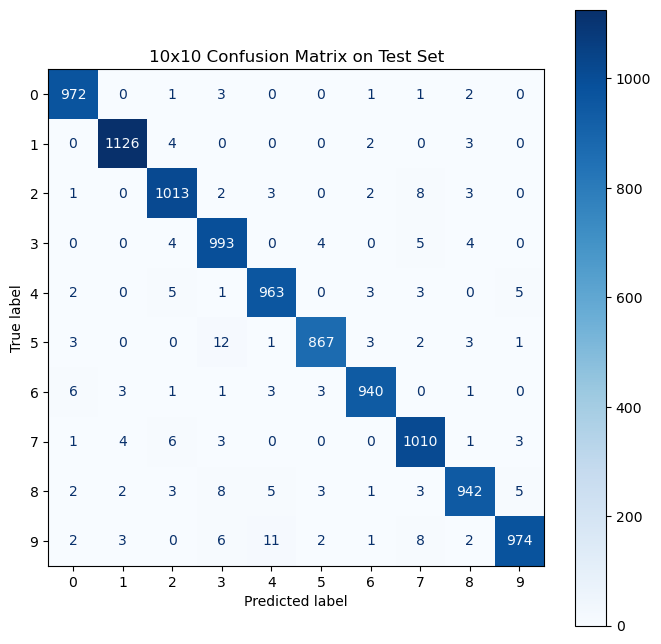

In [9]:
# 1. Evaluate on 10,000 unseen test images
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"🎯 Test Accuracy: {acc*100:.2f}% (Loss: {loss:.4f})")

# 2. Get predictions (argmax gets the digit with the highest probability)
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

# 3. 1-Line 10x10 Confusion Matrix!
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
plt.title("10x10 Confusion Matrix on Test Set")
plt.show()

---
## 8. 🔬 Error Analysis: Easy Plot of Misclassified Digits


Total mistakes: 200 out of 10,000 images


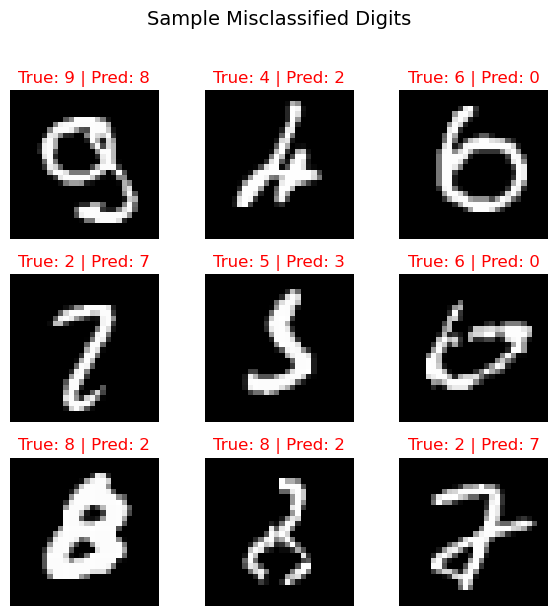

In [10]:
# Find indices where prediction does not match true label
bad_idx = np.where(y_pred != y_test)[0]
print(f"Total mistakes: {len(bad_idx)} out of 10,000 images")

# Display first 9 mistakes in a simple loop
plt.figure(figsize=(6, 6))
for i in range(9):
    idx = bad_idx[i]
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Sample Misclassified Digits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. 🔮 Live Single-Image Prediction Demo (Only 3 Lines!)


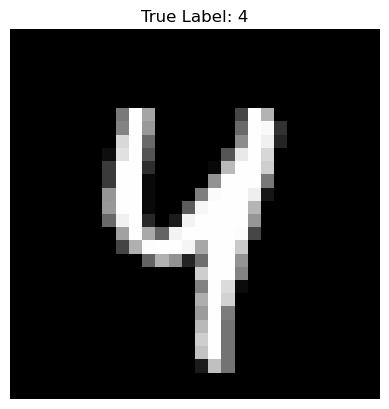

Predicted Digit: 4 with Confidence: 100.00%


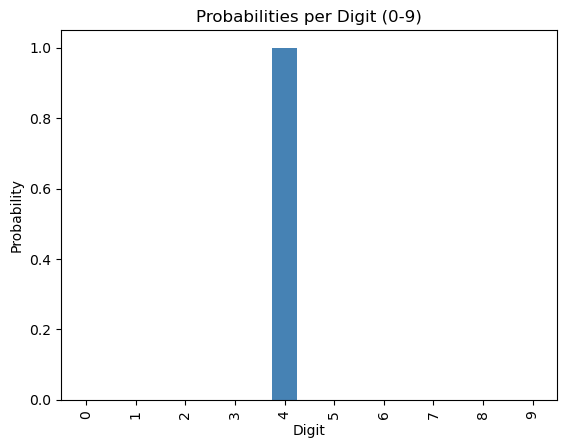

In [11]:
# Test any image by index (e.g. index 42)
idx = 42

# 1. Show image
plt.imshow(X_test[idx], cmap='gray')
plt.title(f"True Label: {y_test[idx]}")
plt.axis('off')
plt.show()

# 2. Predict probability distribution & class
probs = model.predict(X_test[idx:idx+1], verbose=0)[0]
print(f"Predicted Digit: {probs.argmax()} with Confidence: {probs.max()*100:.2f}%")

# 3. Quick 1-line bar chart of class probabilities
pd.Series(probs).plot.bar(title="Probabilities per Digit (0-9)", xlabel="Digit", ylabel="Probability", color='steelblue')
plt.show()

---
## 💡 Student Exercises & Next Steps
1. **Try removing Normalization**: Train on `X_train * 255.0` (unnormalized) and see what happens to loss!
2. **Try removing Dropout**: Remove `Dropout(0.2)` and observe the gap between training and validation accuracy.
3. **Bridge to CNNs**: Why do we need CNNs? Notice how `Flatten` destroys 2D spatial relationships between nearby pixels. In the next lecture, Convolutional layers will solve this!
